# Analysis of the Narratives used in the Deutsche Wochenschau from 1940-1945

# Preprocessing and Data Cleaning

In [37]:
import pandas as pd
import numpy as np
from pathlib import Path
import os
from dotenv import load_dotenv
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
import ruptures as rpt
import scipy.cluster.hierarchy as sch
from scipy.stats import spearmanr, pearsonr
import networkx as nx
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.preprocessing import StandardScaler

In [38]:
load_dotenv(override=True)

NARRATIVES_DATA_TSV = Path(os.getenv("NARRATIVES_DATA_TSV")).resolve()
print(NARRATIVES_DATA_TSV)

D:\Dokumente\Studium\Master\3. Semester\Cultural Analytics\Neuer Ordner\cultural_analytics_project\src\analysis\narratives.tsv


In [39]:
# Load dataset
df = pd.read_csv(NARRATIVES_DATA_TSV, delimiter="\t")
print(df.columns.tolist())

# Extract year and episode from filestem (e.g. "511_1940")
df[["episode", "year"]] = df["filestem"].str.extract(r"(\d+)_(\d{4})").astype(int)

# Sort chronologically
df = df.sort_values("year")

['filestem', 'chapter', 'unit_of_analysis', 'actor_configuration', 'narrative_framing', 'legitimation_strategy', 'enemy_moral_status', 'embodiment_mode', 'violence_visibility', 'agency_level', 'narrative_summary', 'confidence_score']


In [40]:
multi_label_cols = [
    "narrative_framing",
    "embodiment_mode",
    "legitimation_strategy",
    "enemy_moral_status",
    "actor_configuration",
    "violence_visibility"
]

single_label_cols = [
    "agency_level"
]

Some quick checks and data cleaning:

In [41]:
print("Percentage of multi-label cases in violence_visibility: ", df["violence_visibility"].str.contains(";").mean())

Percentage of multi-label cases in violence_visibility:  0.02191464821222607


In [42]:
for col in multi_label_cols:
    print(col, df[col].isna().sum())

df["violence_visibility"].value_counts()


narrative_framing 0
embodiment_mode 0
legitimation_strategy 0
enemy_moral_status 0
actor_configuration 0
violence_visibility 0


violence_visibility
implied          1932
absent           1394
shown              66
implied;shown      54
shown;implied      16
a;b;s;e;n;t         4
i;m;p;l;i;e;d       2
Name: count, dtype: int64

In [43]:
df["violence_visibility"] = (
    df["violence_visibility"]
    .str.replace("i;m;p;l;i;e;d", "implied", regex=False)
    .str.replace("a;b;s;e;n;t", "absent", regex=False)
    .str.split(";")
    .apply(lambda x: ";".join(sorted(x)))
)

df["violence_visibility"].value_counts()

violence_visibility
implied          1934
absent           1398
implied;shown      70
shown              66
Name: count, dtype: int64

In [44]:
df["agency_level"].value_counts()

agency_level
high          2746
medium         656
low             58
none             4
['medium']       2
['high']         2
Name: count, dtype: int64

In [45]:
df["agency_level"] = (
    df["agency_level"]
    .str.replace("['medium']", "medium", regex=False)
    .str.replace("['high']", "high", regex=False)
    .str.split(";")
    .apply(lambda x: ";".join(sorted(x)))
)

df["agency_level"].value_counts()

agency_level
high      2748
medium     658
low         58
none         4
Name: count, dtype: int64

Make sure all categories are written in the same way and lists of categories are in the same order:

In [46]:
for col in multi_label_cols:
    # Convert semicolon-separated strings to lists
    df[col] = df[col].str.split(";")
    
    # Remove whitespace and lowercase everything
    df[col] = df[col].apply(lambda lst: [x.strip().lower() for x in lst if x])
    
    # Sort the labels so that order does not matter
    df[col] = df[col].apply(lambda lst: sorted(lst))
    
    # Convert back to string for get_dummies
    df[col] = df[col].apply(lambda lst: ";".join(lst))

Check that no typos are included anymore:

In [47]:
for col in multi_label_cols:
    all_labels = set()
    df[col].str.split(";").apply(all_labels.update)
    print(col, all_labels)

narrative_framing {'technological_modernity', 'occupation_normalization', 'soldier_as_victim', 'defensive_war', 'heroic_combat', 'sacrificial_martyrdom', 'humanitarian_relief', 'comradely_front', 'liberation_mission', 'collective_military', 'retaliatory', 'cultural_guardianship', 'none', 'civilizational_struggle', 'inevitable_victory', 'administrative_normality'}
embodiment_mode {'emotionally_expressivity', 'emotionally_restrained', 'emotional_expressivity', 'neutral_military_presence', 'disciplined_masculinity', 'invulnerable_body', 'wounded_body', 'eroticized_body', 'none'}
legitimation_strategy {'ideological', 'humanitarian', 'civilizing', 'preventive', 'existential_threat', 'none', 'defensive', 'retaliatory'}
enemy_moral_status {'dehumanized_enemy', 'weaker_enemy', 'criminalized_enemy', 'existential_threat', 'none', 'legitimate_opponent'}
actor_configuration {'individual_hero', 'enemy_focus', 'mixed_interaction', 'collective_military', 'civilian_collective'}
violence_visibility {'s

In [48]:
for col in multi_label_cols:
    dummies = df[col].str.get_dummies(sep=";")
    dummies.columns = [f"{col}_{c}" for c in dummies.columns]
    df = pd.concat([df, dummies], axis=1)

for col in single_label_cols:
    dummies = pd.get_dummies(df[col])
    dummies.columns = [f"{col}_{c}" for c in dummies.columns]
    df = pd.concat([df, dummies], axis=1)

In [49]:
# compute yearly frequencies
yearly = df.groupby("year").mean(numeric_only=True)

# compute frequencies per episode
episode_means = df.groupby("episode").mean(numeric_only=True)

## Plot trends over time

Show the trends for all narratives:

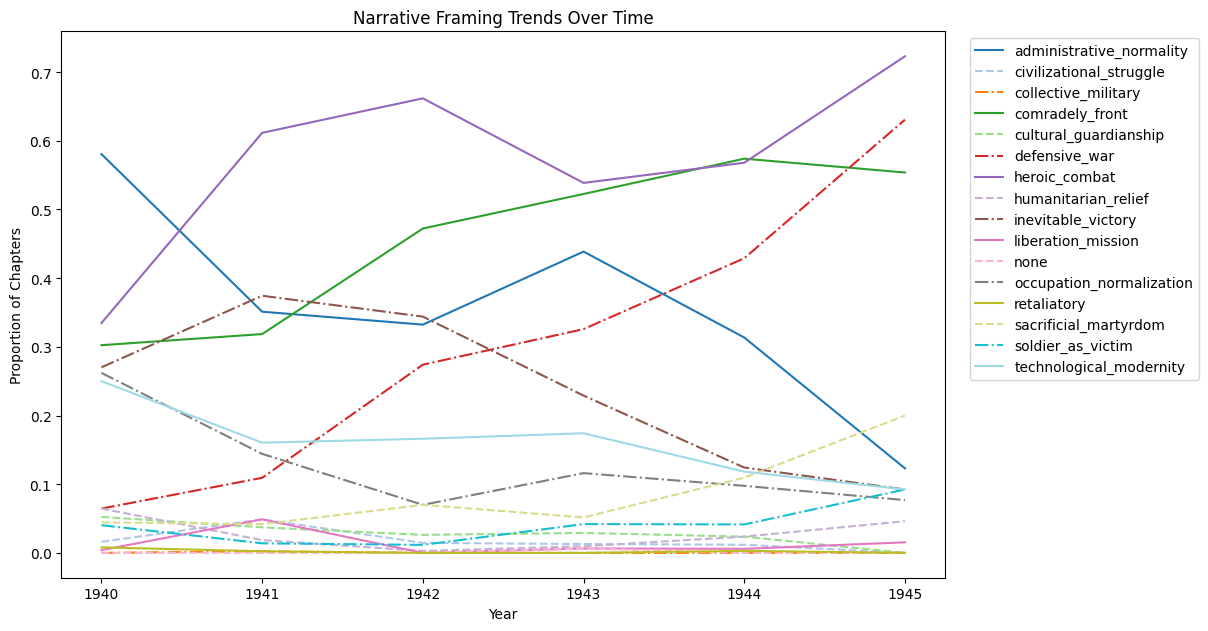

In [50]:
# plot trends over time
narrative_cols = [c for c in yearly.columns if "narrative_framing_" in c]

plt.figure(figsize=(12,6))

colors = plt.cm.tab20(np.linspace(0, 1, len(narrative_cols)))
line_styles = ["-", "--", "-."]

for i, col in enumerate(narrative_cols):
    plt.plot(
        yearly.index,
        yearly[col],
        label=col.replace("narrative_framing_", ""),
        color=colors[i],
        linestyle=line_styles[i % len(line_styles)]
    )

plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.title("Narrative Framing Trends Over Time")
plt.ylabel("Proportion of Chapters")
plt.xlabel("Year")
plt.show()

Only show the top 10 narratives:

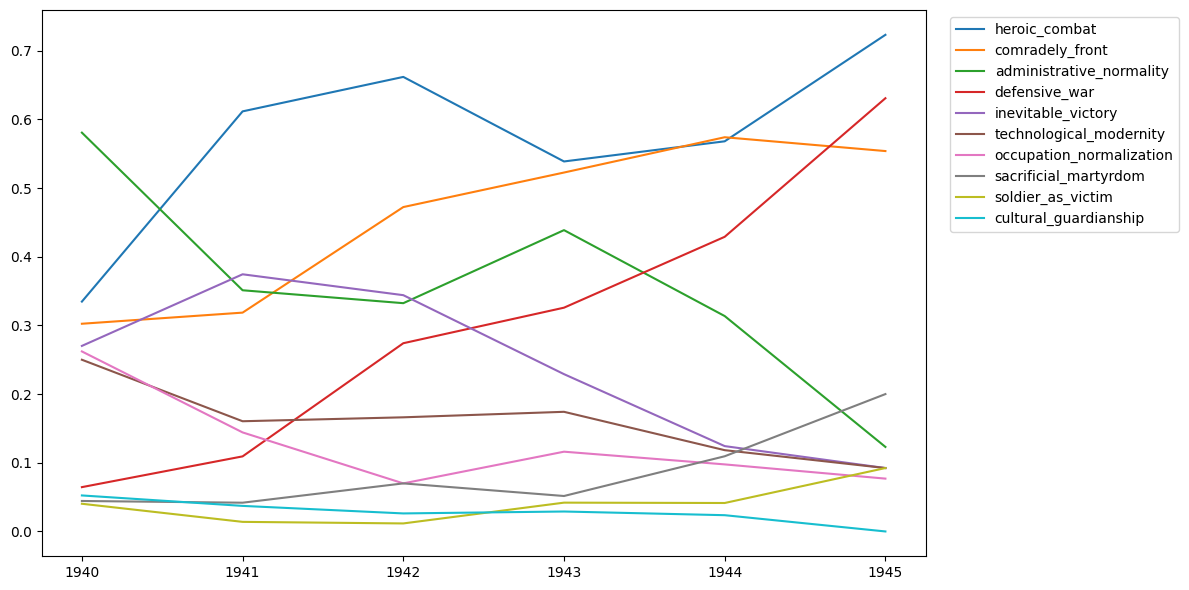

In [51]:
top_n = 10

top_cols = (
    yearly[narrative_cols]
    .mean()
    .sort_values(ascending=False)
    .head(top_n)
    .index
)

plt.figure(figsize=(12,6))

colors = plt.cm.tab10(np.linspace(0,1,len(top_cols)))

for i, col in enumerate(top_cols):
    plt.plot(yearly.index, yearly[col],
             label=col.replace("narrative_framing_", ""),
             color=colors[i])

plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()

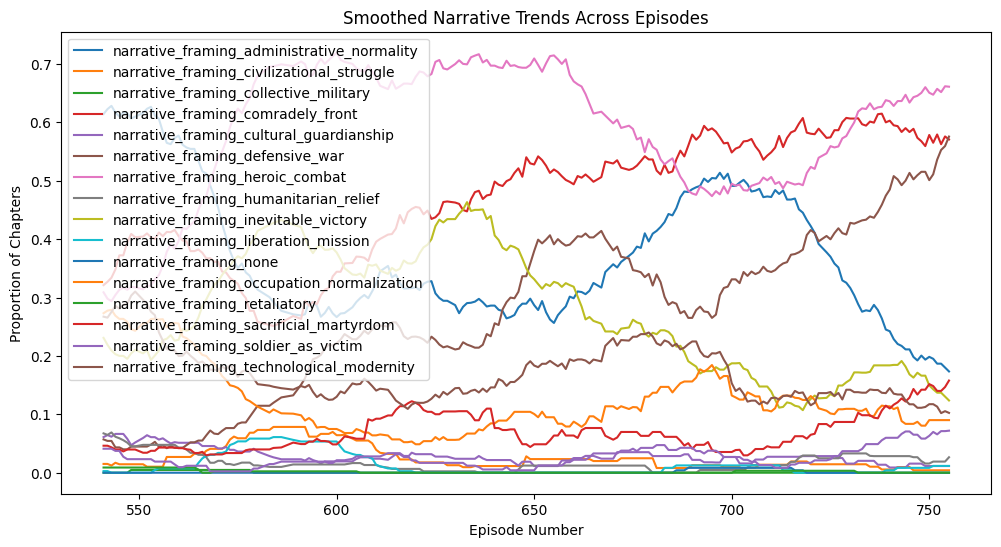

In [52]:
# plot trends grouped by episode
narrative_cols = [c for c in episode_means.columns if "narrative_framing_" in c]

smooth = episode_means[narrative_cols].rolling(30).mean()

smooth.plot(figsize=(12,6))
plt.xlabel("Episode Number")
plt.ylabel("Proportion of Chapters")
plt.title("Smoothed Narrative Trends Across Episodes")
plt.show()

In [53]:
yearly.loc[1941, "narrative_framing_inevitable_victory"]

np.float64(0.3744186046511628)

In [54]:
col = "narrative_framing_inevitable_victory"

max_episode = episode_means[col].idxmax()
max_value = episode_means[col].max()

print(f"Maximum {col}: {max_value}")
print(f"Episode: {max_episode}")

Maximum narrative_framing_inevitable_victory: 1.0
Episode: 608


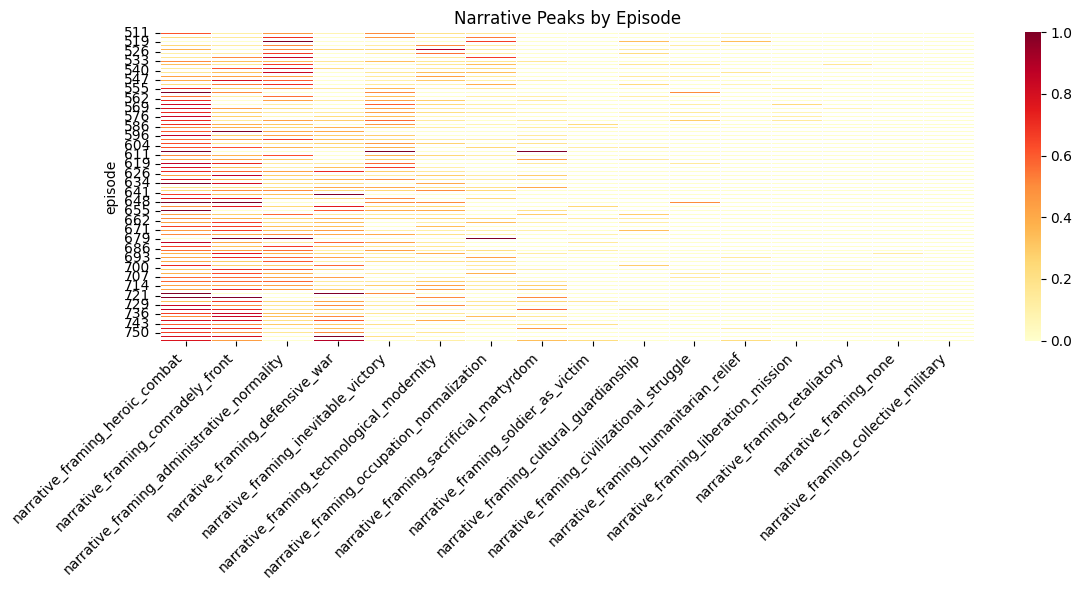

In [55]:
# sort narratives by average importance
sorted_cols = episode_means[narrative_cols].mean().sort_values(ascending=False).index

plt.figure(figsize=(12,6))

sns.heatmap(
    episode_means[sorted_cols],
    cmap="YlOrRd",
    linewidths=0.5
)

plt.title("Narrative Peaks by Episode")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

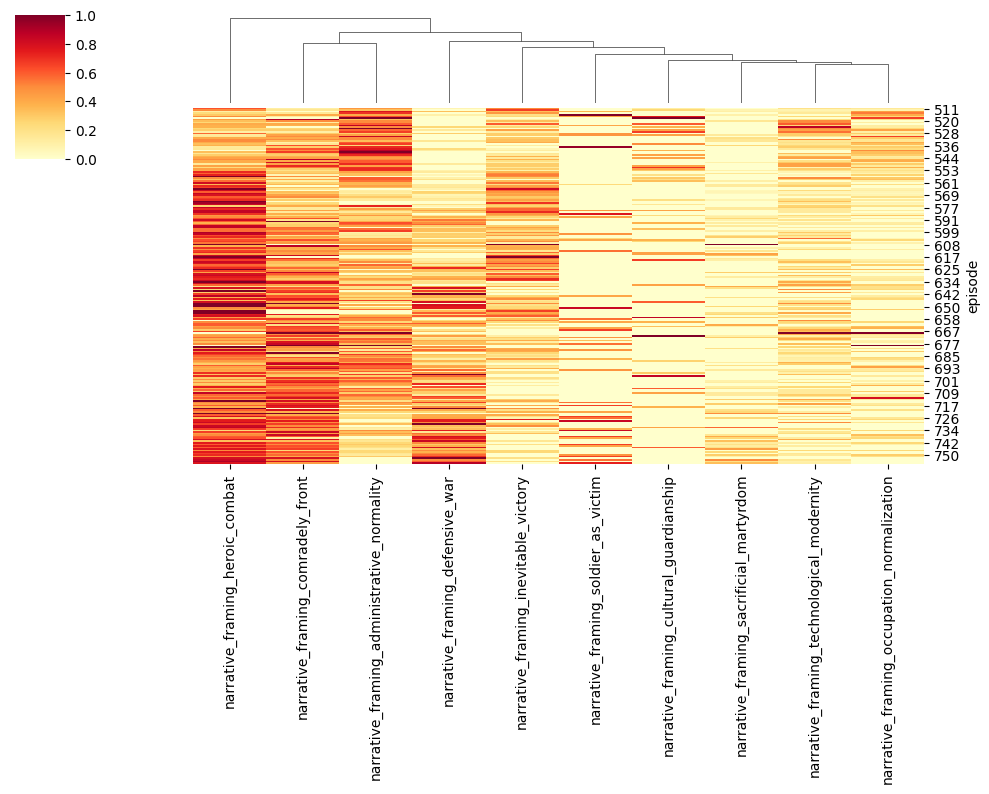

In [56]:
top_n = 10

top_narratives = (
    episode_means[narrative_cols]
    .mean()
    .sort_values(ascending=False)
    .head(top_n)
    .index
)

data = episode_means[top_narratives]

sns.clustermap(
    data,
    cmap="YlOrRd",
    col_cluster=True,
    row_cluster=False,
    figsize=(10,8),
    standard_scale=1
)

plt.show()

Compute Spearman correlation:

In [57]:
results = []

time = episode_means.index.values   # episodes

for col in top_cols:
    rho, p = spearmanr(time, episode_means[col])
    
    results.append({
        "narrative": col.replace("narrative_framing_", ""),
        "spearman_rho": rho,
        "p_value": p
    })

trend_df = pd.DataFrame(results).sort_values("spearman_rho", ascending=False)

print(trend_df)

                  narrative  spearman_rho       p_value
3             defensive_war      0.651417  3.670475e-29
1           comradely_front      0.442246  1.969523e-12
0             heroic_combat      0.223072  6.552221e-04
7     sacrificial_martyrdom      0.168433  1.050310e-02
8         soldier_as_victim      0.154710  1.889180e-02
5   technological_modernity     -0.215456  1.007355e-03
9     cultural_guardianship     -0.249856  1.283950e-04
6  occupation_normalization     -0.281123  1.505981e-05
2  administrative_normality     -0.324230  4.985862e-07
4        inevitable_victory     -0.334735  1.996933e-07


In [58]:
def plot_category_trends(yearly_df, prefix, title):
    
    cols = [c for c in yearly_df.columns if c.startswith(prefix)]
    
    plt.figure(figsize=(12,6))
    
    colors = plt.cm.tab20(np.linspace(0,1,len(cols)))
    line_styles = ["-", "--", "-."]
    
    for i, col in enumerate(cols):
        label = col.replace(prefix, "")
        
        plt.plot(
            yearly_df.index,
            yearly_df[col],
            label=label,
            color=colors[i],
            linestyle=line_styles[i % len(line_styles)]
        )
    
    plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
    plt.tight_layout()
    
    plt.title(title)
    plt.ylabel("Proportion of Chapters")
    plt.xlabel("Year")
    
    plt.show()

Plot trends for other dimensions:

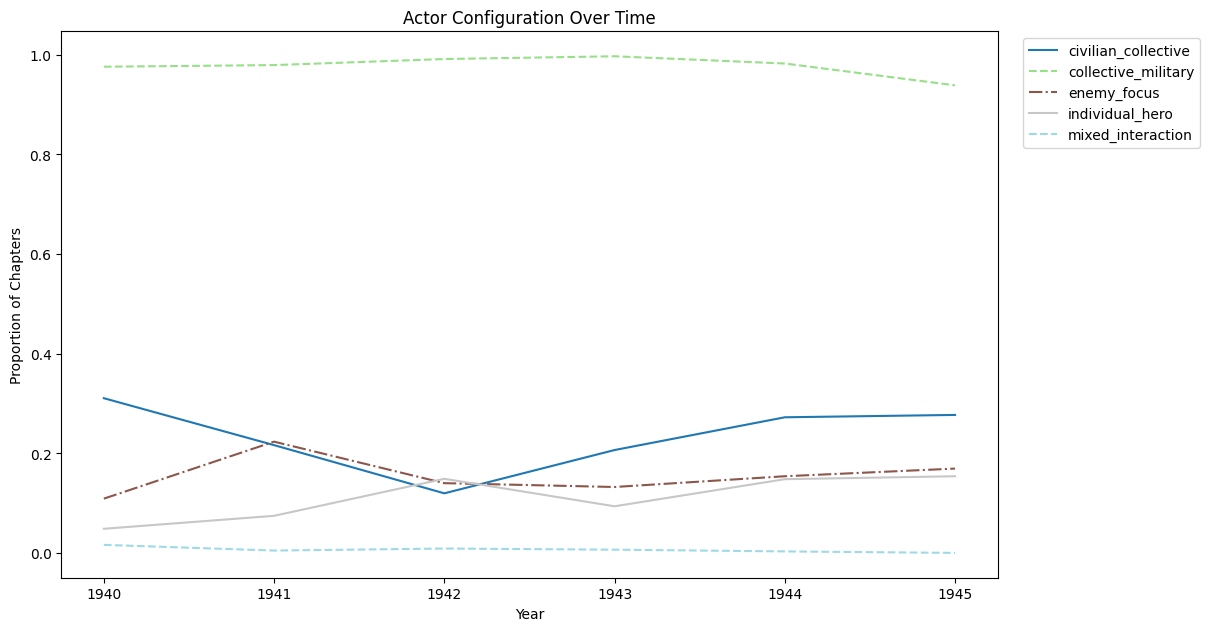

In [59]:
plot_category_trends(
    yearly,
    "actor_configuration_",
    "Actor Configuration Over Time"
)

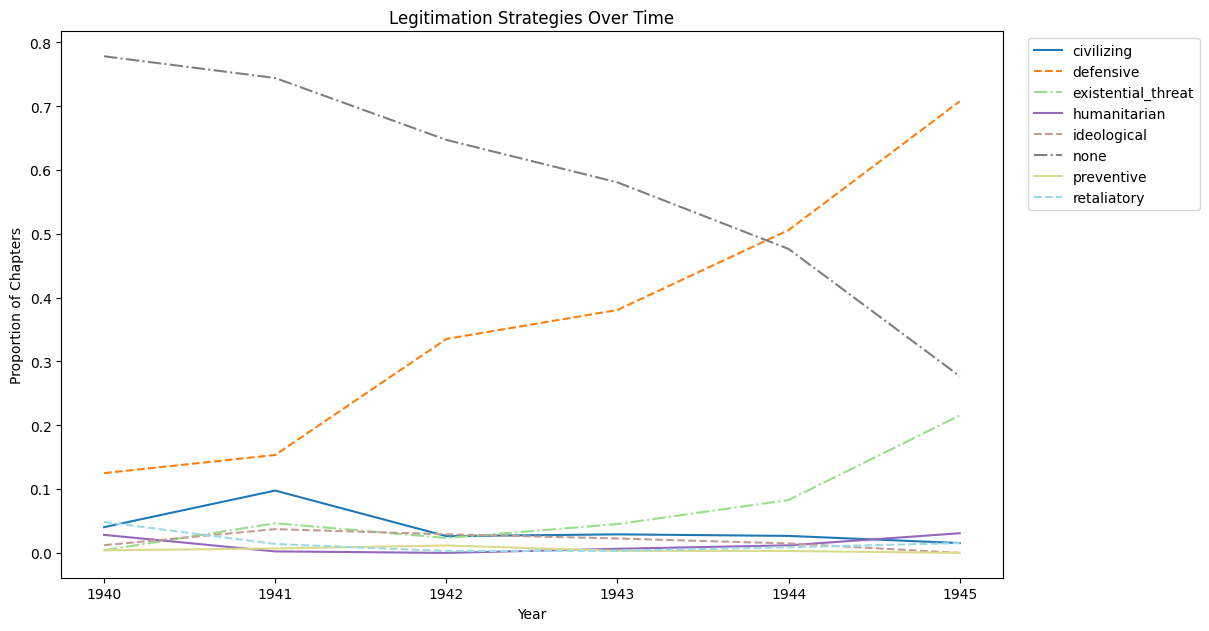

In [60]:
plot_category_trends(
    yearly,
    "legitimation_strategy_",
    "Legitimation Strategies Over Time"
)

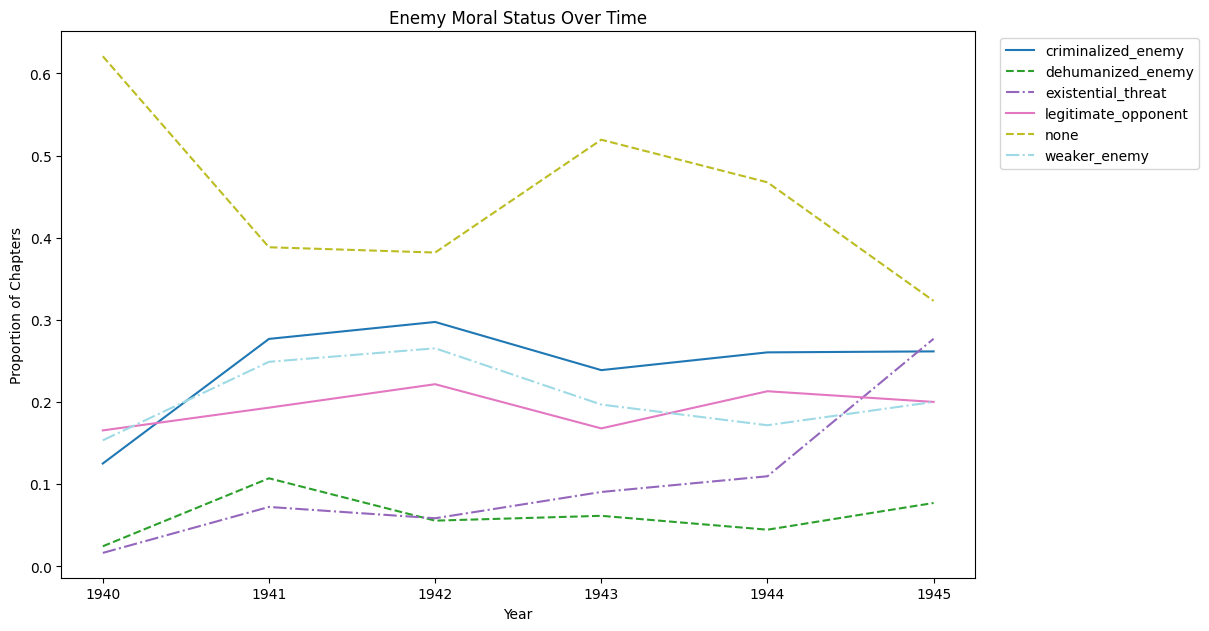

In [61]:
plot_category_trends(
    yearly,
    "enemy_moral_status_",
    "Enemy Moral Status Over Time"
)

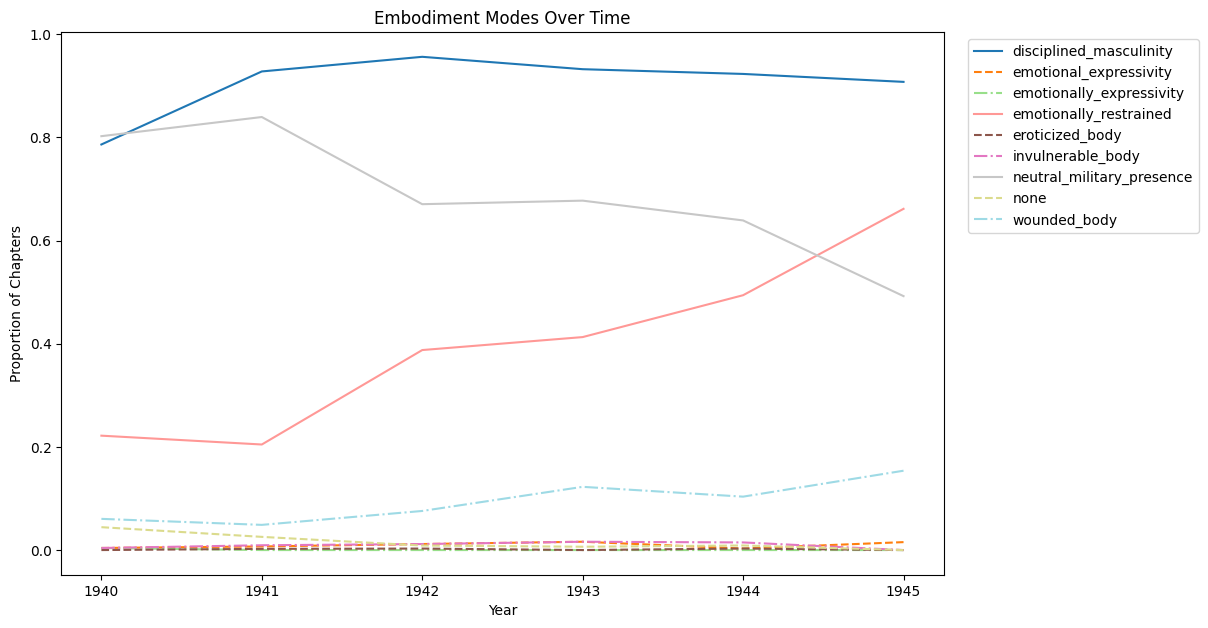

In [62]:
plot_category_trends(
    yearly,
    "embodiment_mode_",
    "Embodiment Modes Over Time"
)

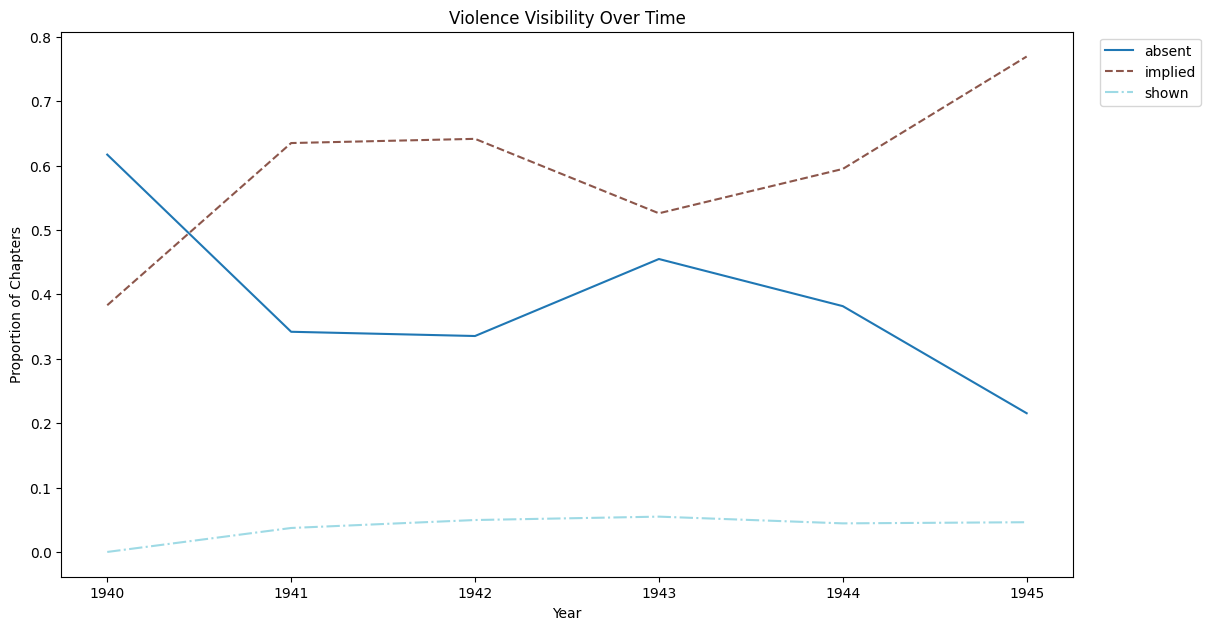

In [63]:
plot_category_trends(
    yearly,
    "violence_visibility_",
    "Violence Visibility Over Time"
)

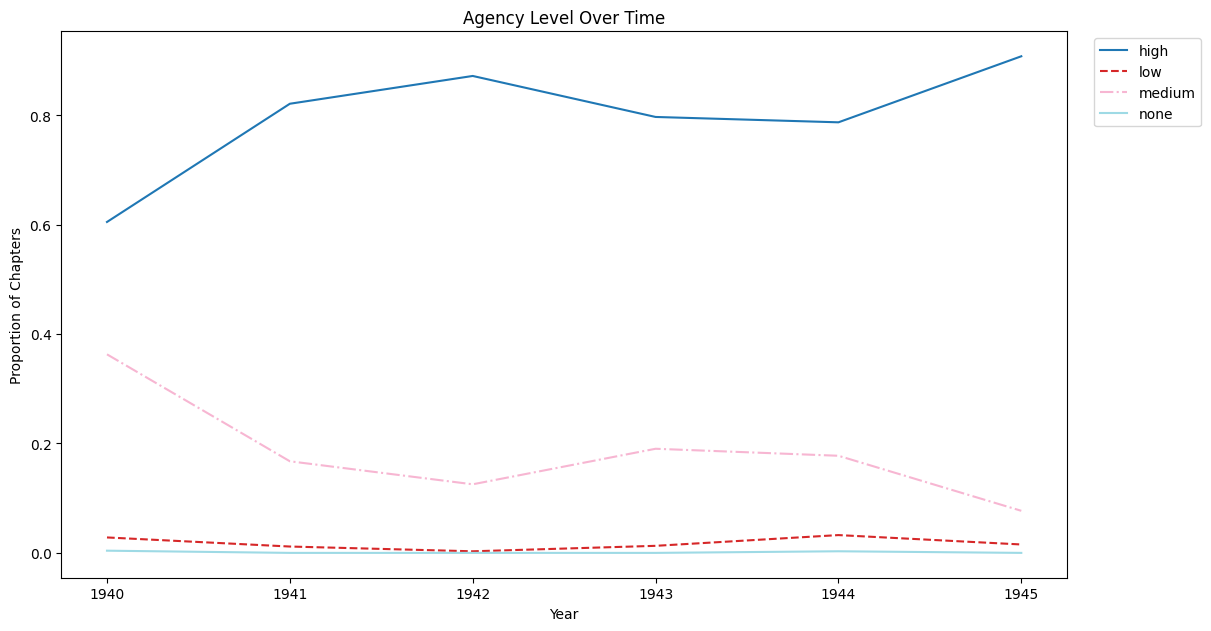

In [64]:
plot_category_trends(
    yearly,
    "agency_level_",
    "Agency Level Over Time"
)

## Correlation Analysis

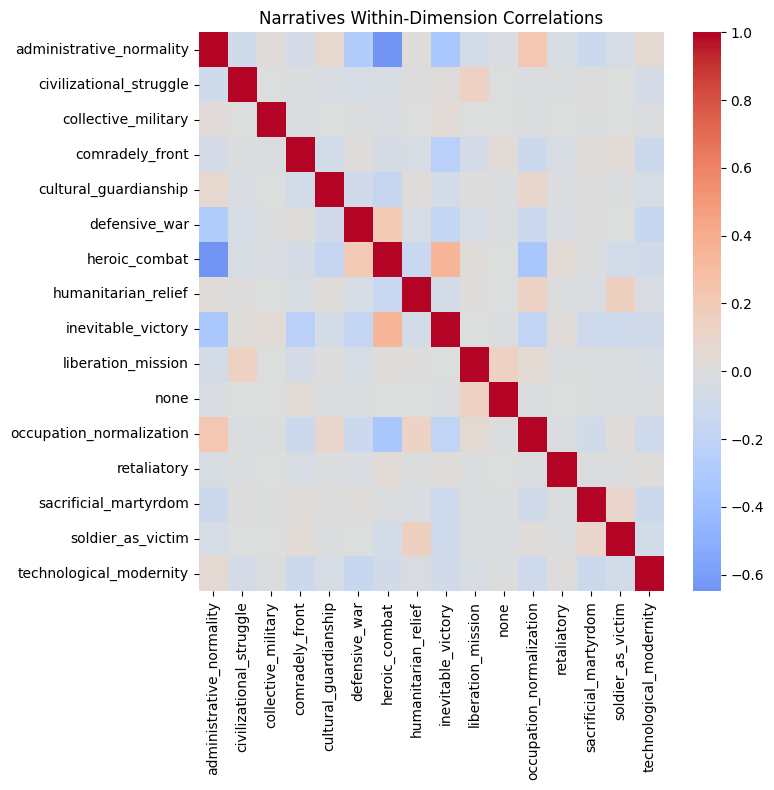

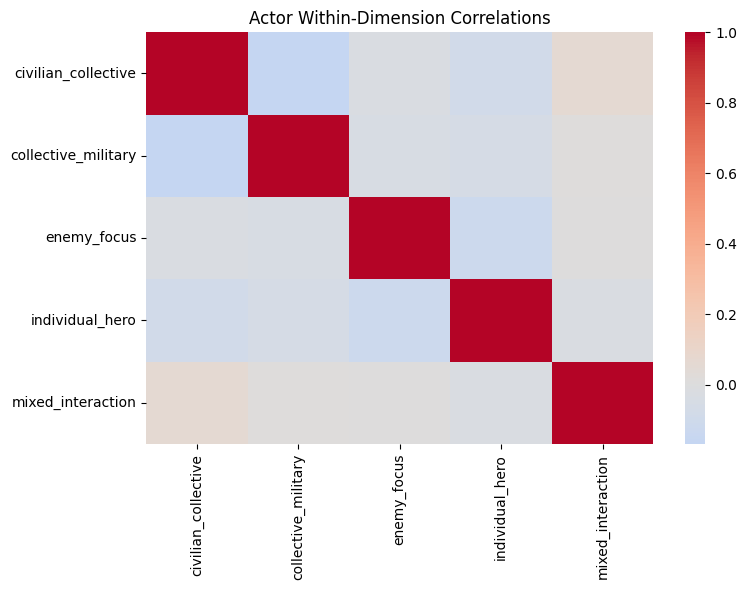

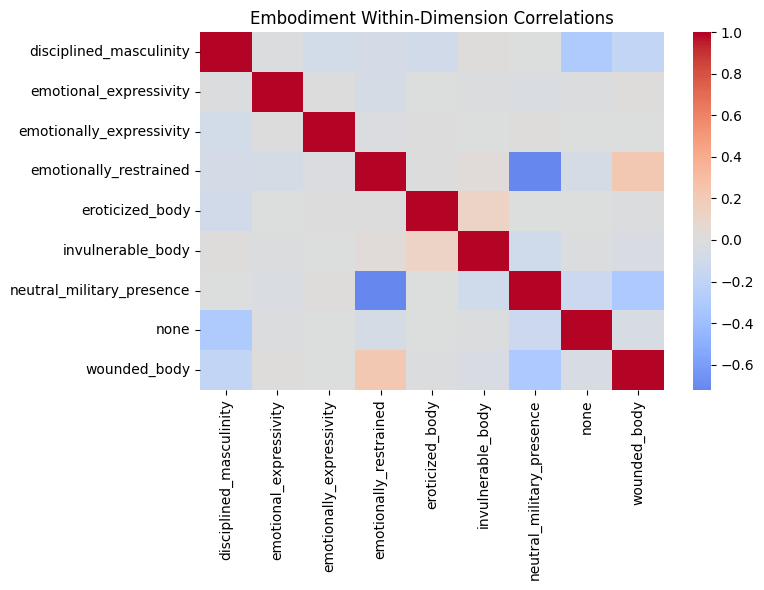

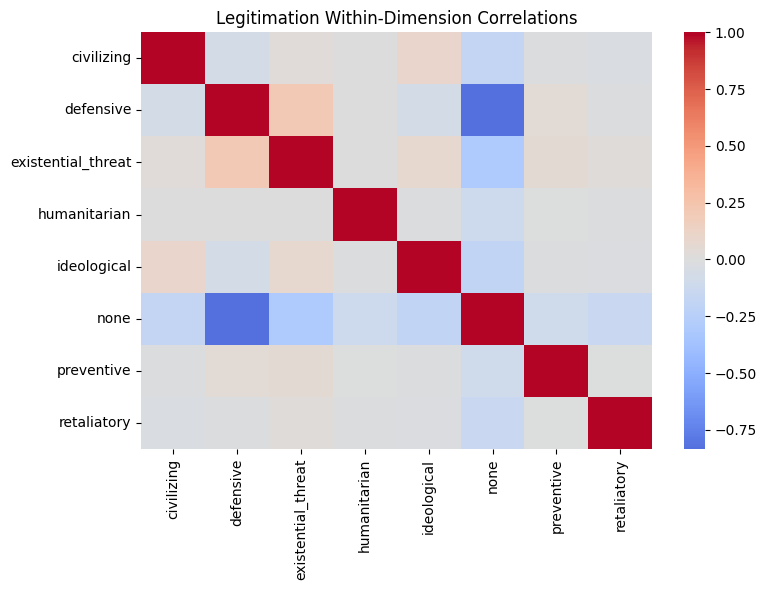

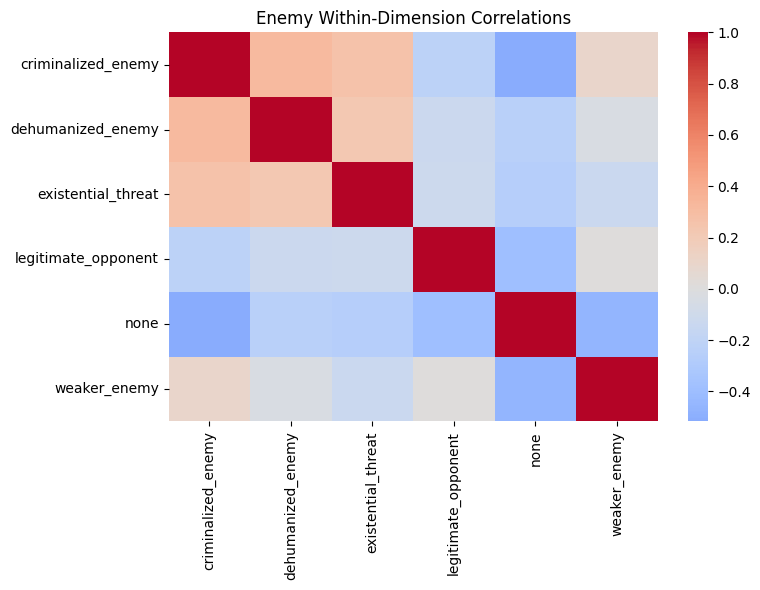

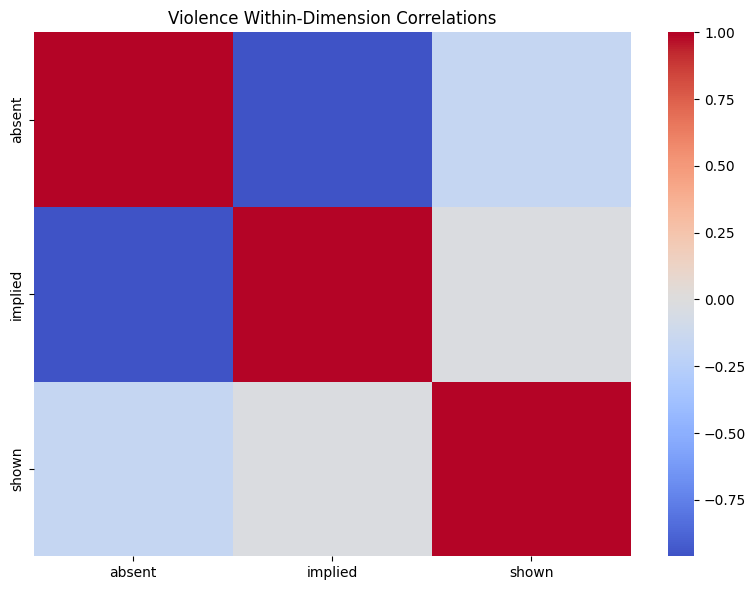

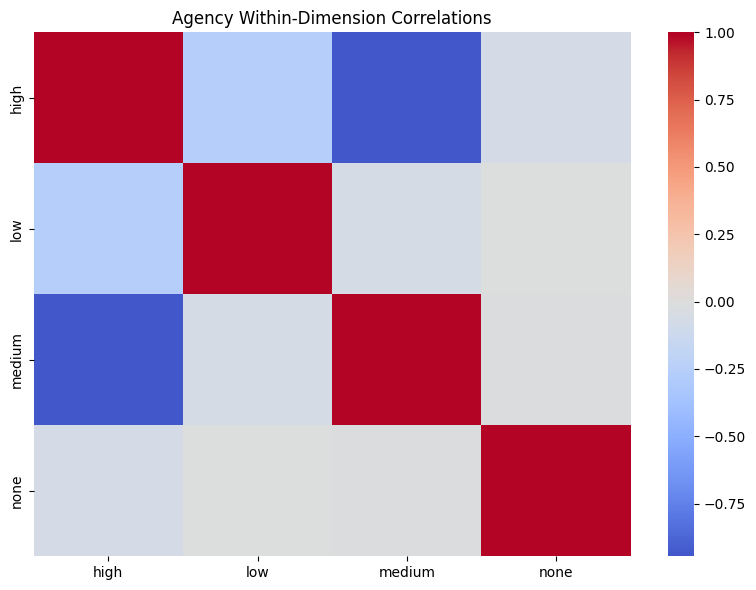

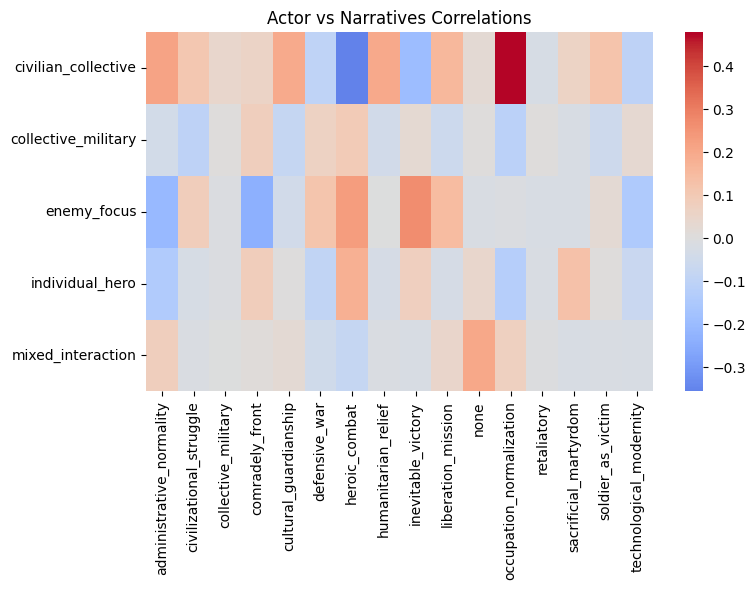

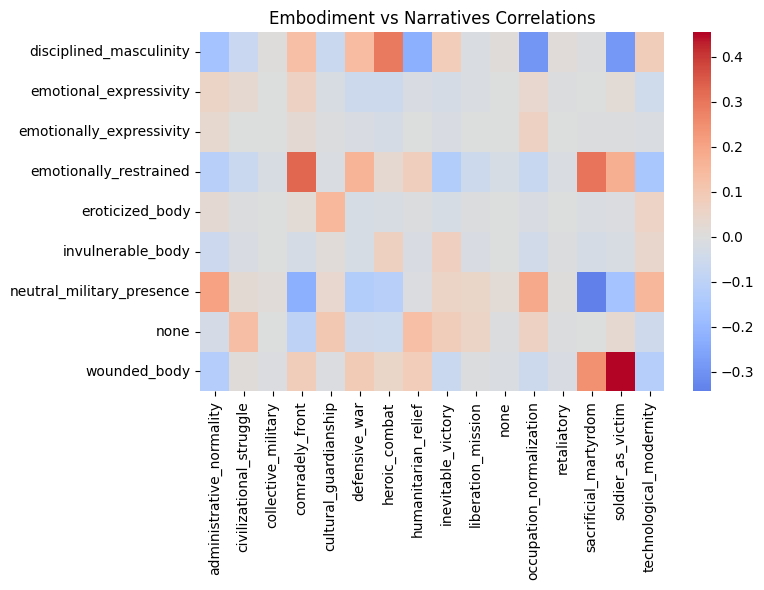

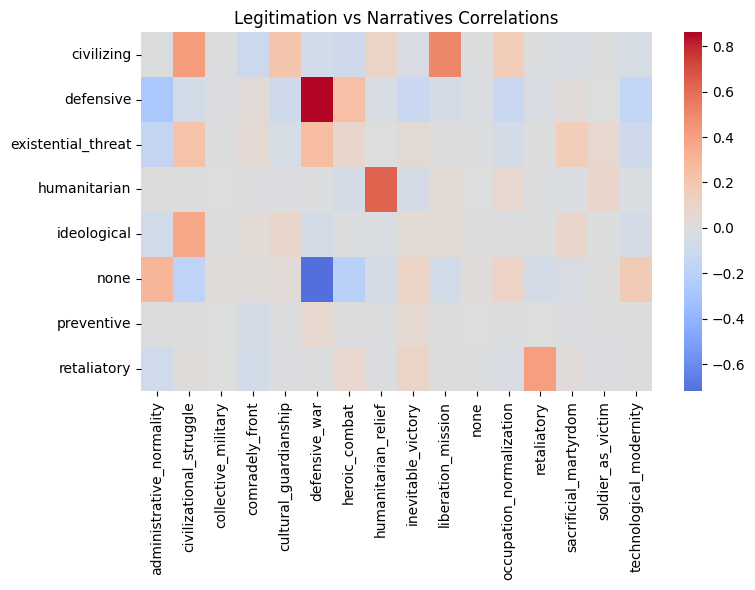

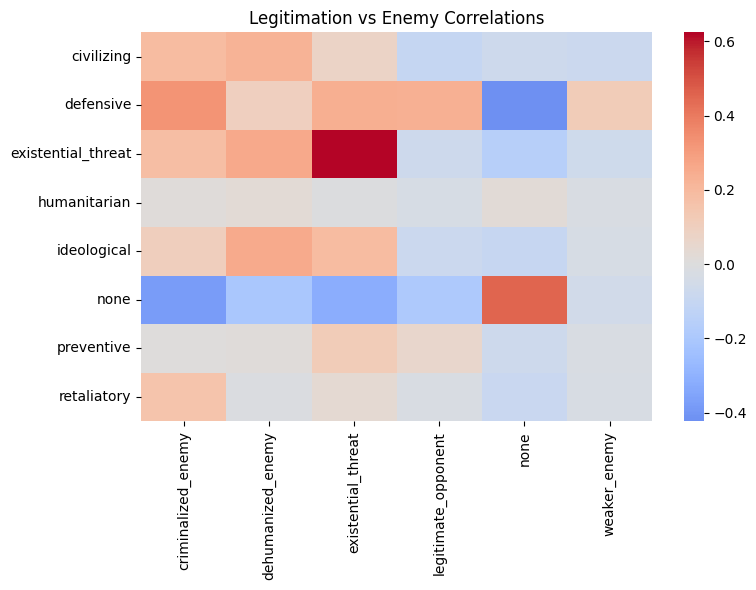

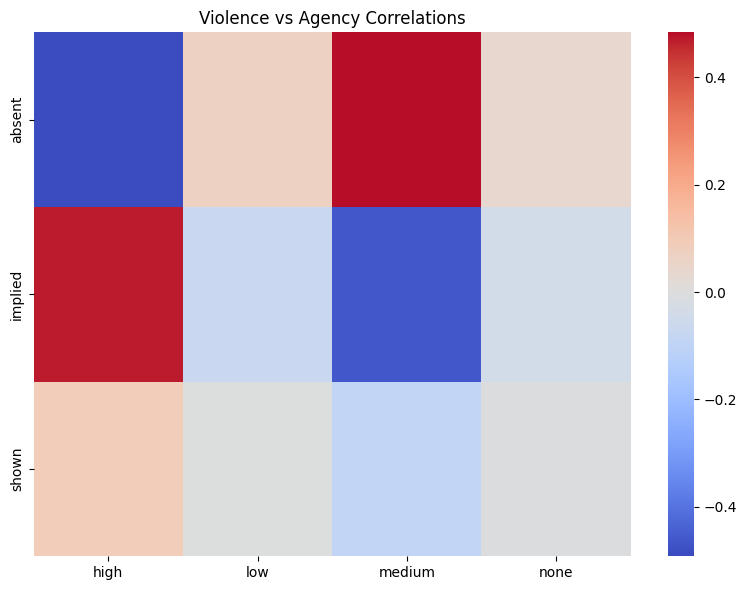

In [65]:

# identify dummy columns per dimension
dimensions = {
    "Narratives": "narrative_framing_",
    "Actor": "actor_configuration_",
    "Embodiment": "embodiment_mode_",
    "Legitimation": "legitimation_strategy_",
    "Enemy": "enemy_moral_status_",
    "Violence": "violence_visibility_",
    "Agency": "agency_level_"
}

def plot_heatmap(corr_df, title, row_prefix=None, col_prefix=None):
    """
    Plots a heatmap with fixed size and optionally strips prefixes from labels.
    """

    row_labels = corr_df.index
    col_labels = corr_df.columns

    if row_prefix:
        row_labels = [r.replace(row_prefix, "") for r in row_labels]

    if col_prefix:
        col_labels = [c.replace(col_prefix, "") for c in col_labels]

    fig_width = max(8, len(col_labels)*0.5)
    fig_height = max(6, len(row_labels)*0.5)

    plt.figure(figsize=(fig_width, fig_height))

    sns.heatmap(
        corr_df,
        cmap="coolwarm",
        center=0,
        xticklabels=col_labels,
        yticklabels=row_labels
    )

    plt.title(title)
    plt.tight_layout()
    plt.show()
dimension_cols = {name: [c for c in df.columns if c.startswith(prefix)] for name, prefix in dimensions.items()}

# compute within-dimension correlations
for dim, cols in dimension_cols.items():
    if len(cols) < 2:
        continue
    corr = df[cols].corr()
    prefix = dimensions[dim]

    plot_heatmap(corr, f"{dim} Within-Dimension Correlations",  row_prefix=prefix, col_prefix=prefix)

# compute cross-dimension correlations
cross_pairs = [
    ("Actor", "Narratives"),
    ("Embodiment", "Narratives"),
    ("Legitimation", "Narratives"),
    ("Legitimation", "Enemy"),
    ("Violence", "Agency")
]

for dim1, dim2 in cross_pairs:
    cols1 = dimension_cols[dim1]
    cols2 = dimension_cols[dim2]
    corr = df[cols1 + cols2].corr().loc[cols1, cols2]
    plot_heatmap(
        corr,
        f"{dim1} vs {dim2} Correlations",
        row_prefix=dimensions[dim1],
        col_prefix=dimensions[dim2]
    )

Print Pearson correlation for specific narratives:

In [66]:
pairs = [
    ("inevitable_victory", "heroic_combat"),
    ("defensive_war", "heroic_combat")
]


for a, b in pairs:
    col1 = f"narrative_framing_{a}"
    col2 = f"narrative_framing_{b}"
    r, p = pearsonr(df[col1], df[col2])
    print(f"{a} – {b}: r={r:.3f}, p={p:.4f}")

inevitable_victory – heroic_combat: r=0.345, p=0.0000
defensive_war – heroic_combat: r=0.195, p=0.0000


Plot a network of Co-Occurences

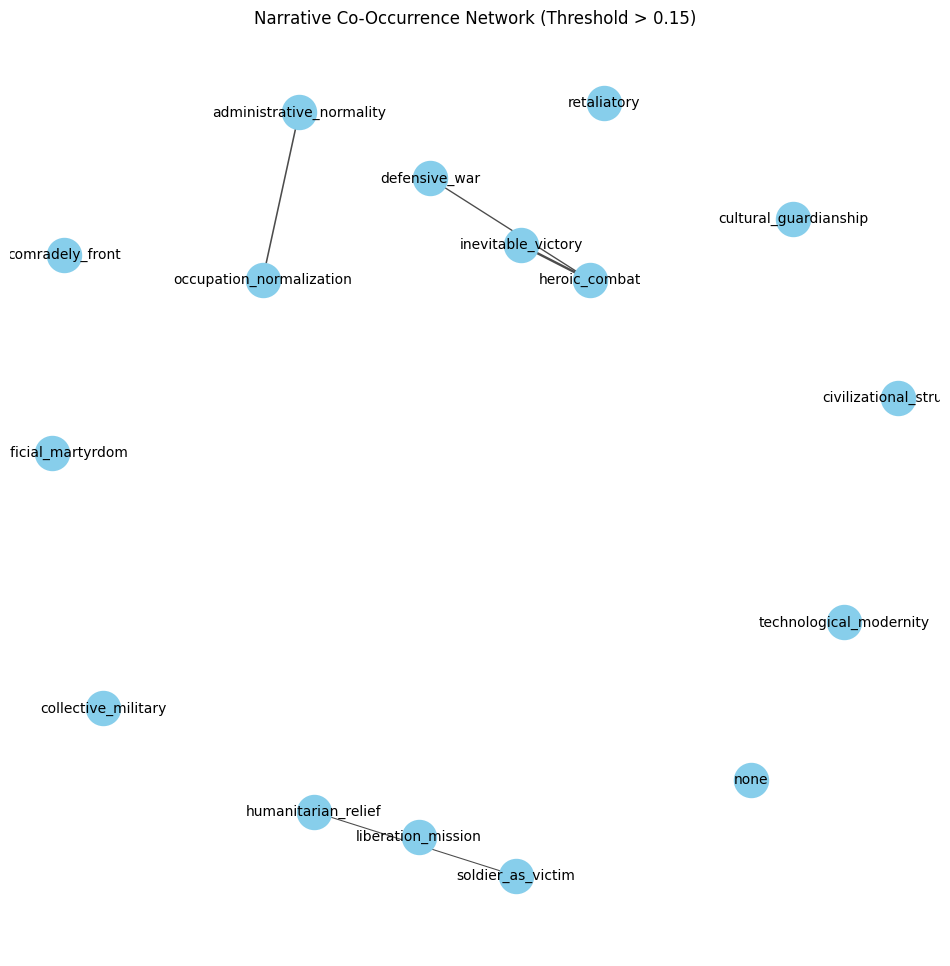

In [67]:
# Narrative Co-Occurrence Network
narr_cols = dimension_cols["Narratives"]
# Compute correlation matrix
corr_narr = df[narr_cols].corr()

# Threshold for edges
threshold = 0.15

G = nx.Graph()
# Add nodes
for col in narr_cols:
    G.add_node(col.replace("narrative_framing_", ""))

# Add edges for correlations above threshold
for i, col1 in enumerate(narr_cols):
    for j, col2 in enumerate(narr_cols):
        if i < j and corr_narr.loc[col1, col2] > threshold:
            G.add_edge(
                col1.replace("narrative_framing_", ""),
                col2.replace("narrative_framing_", ""),
                weight=corr_narr.loc[col1, col2]
            )

# Draw network
plt.figure(figsize=(12,12))
pos = nx.spring_layout(G, k=0.5, seed=42)
edges = G.edges(data=True)
nx.draw_networkx_nodes(G, pos, node_size=600, node_color='skyblue')
nx.draw_networkx_labels(G, pos, font_size=10)
nx.draw_networkx_edges(G, pos, width=[d['weight']*5 for (u,v,d) in edges], alpha=0.7)
plt.title(f"Narrative Co-Occurrence Network (Threshold > {threshold})")
plt.axis('off')
plt.show()

## Detect narrative shifts

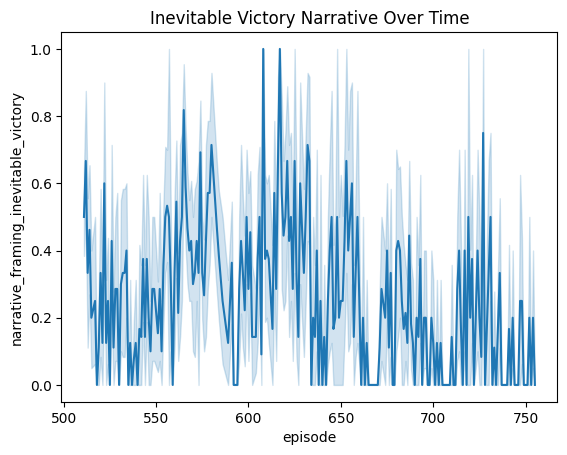

In [70]:
sns.lineplot(
    data=df,
    x="episode",
    y="narrative_framing_inevitable_victory",
    estimator="mean"
)

plt.title("Inevitable Victory Narrative Over Time")
plt.show()

Detect turning points in the narratives:

In [71]:
# detects propaganda turning points
series = episode_means["narrative_framing_inevitable_victory"].values

algo = rpt.Pelt(model="rbf").fit(series)
breaks = algo.predict(pen=3)

# ruptures includes the last index as the series length, remove it
breaks = [b for b in breaks if b < len(series)]

# map to episode numbers
episode_numbers = episode_means.index[breaks].tolist()
print("Detected narrative shifts for 'inevitable_victory' occur at episodes:", episode_numbers)

Detected narrative shifts for 'inevitable_victory' occur at episodes: [553, 662]


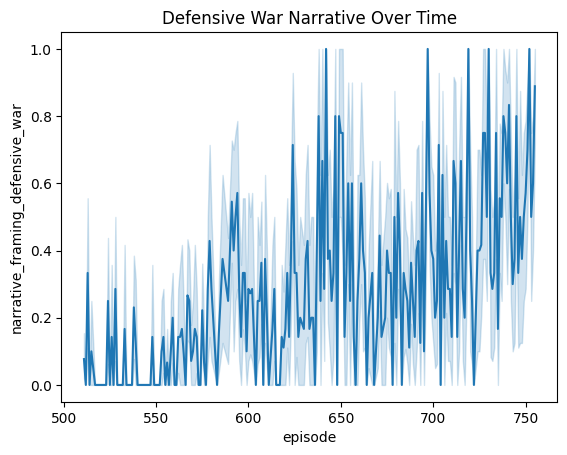

In [72]:
sns.lineplot(
    data=df,
    x="episode",
    y="narrative_framing_defensive_war",
    estimator="mean"
)

plt.title("Defensive War Narrative Over Time")
plt.show()

In [73]:
series = episode_means["narrative_framing_defensive_war"].values

algo = rpt.Pelt(model="rbf").fit(series)
breaks = algo.predict(pen=3)

# ruptures includes the last index as the series length, remove it
breaks = [b for b in breaks if b < len(series)]

# map to episode numbers
episode_numbers = episode_means.index[breaks].tolist()
print("Detected narrative shifts for 'defensive_war' occur at episodes:", episode_numbers)

Detected narrative shifts for 'defensive_war' occur at episodes: [578, 726]


## Find Propaganda "Configurations" with Clustering

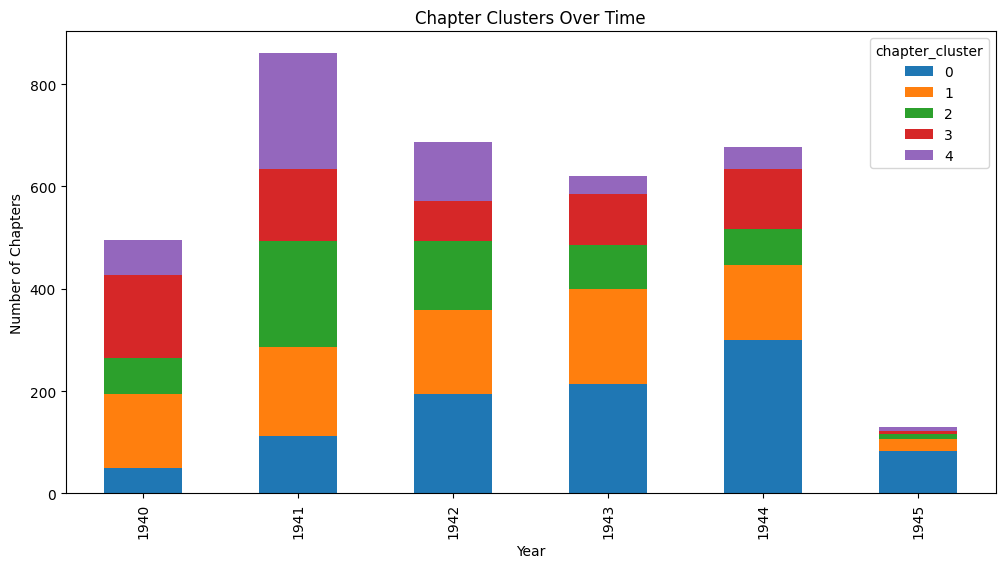

In [93]:
all_dummy_cols = [c for c in df.columns if any(c.startswith(p) for p in dimensions.values())]

X = df[all_dummy_cols]

# Cluster chapters
cluster_model = AgglomerativeClustering(n_clusters=5, linkage='ward')
df['chapter_cluster'] = cluster_model.fit_predict(X)

# Optional: visualize cluster distribution over years
cluster_counts = df.groupby(['year', 'chapter_cluster']).size().unstack(fill_value=0)

cluster_counts.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title("Chapter Clusters Over Time")
plt.ylabel("Number of Chapters")
plt.xlabel("Year")
plt.show()

In [94]:
# group by cluster and compute mean per column
cluster_summary = df.groupby('chapter_cluster')[all_dummy_cols].mean()

# optional: round for readability
cluster_summary = cluster_summary.round(2)

cluster_summary

,narrative_framing_administrative_normality,narrative_framing_civilizational_struggle,narrative_framing_collective_military,narrative_framing_comradely_front,narrative_framing_cultural_guardianship,narrative_framing_defensive_war,narrative_framing_heroic_combat,narrative_framing_humanitarian_relief,narrative_framing_inevitable_victory,narrative_framing_liberation_mission,...,actor_configuration_enemy_focus,actor_configuration_individual_hero,actor_configuration_mixed_interaction,violence_visibility_absent,violence_visibility_implied,violence_visibility_shown,agency_level_high,agency_level_low,agency_level_medium,agency_level_none
chapter_cluster,,,,,,,,,,,,,,,,,,,,,
0,0.13,0.00,0.0,0.47,0.01,0.85,0.80,0.01,0.18,0.00,...,0.24,0.05,0.00,0.02,0.94,0.08,0.97,0.00,0.03,0.0
1,0.57,0.05,0.0,0.56,0.03,0.07,0.29,0.03,0.17,0.01,...,0.01,0.19,0.01,0.94,0.06,0.01,0.92,0.03,0.04,0.0
2,0.17,0.00,0.0,0.46,0.01,0.01,0.89,0.00,0.43,0.00,...,0.06,0.21,0.00,0.01,0.98,0.01,1.00,0.00,0.00,0.0
3,0.90,0.00,0.0,0.43,0.09,0.01,0.01,0.05,0.02,0.00,...,0.05,0.02,0.02,0.96,0.04,0.00,0.01,0.03,0.96,0.0
4,0.15,0.06,0.0,0.16,0.03,0.02,0.87,0.02,0.72,0.09,...,0.49,0.04,0.00,0.01,0.94,0.09,0.94,0.02,0.03,0.0


In [95]:
# Compute top 8 categories per cluster as lists
top_categories_per_cluster = cluster_summary.apply(lambda row: row.nlargest(8).index.tolist(), axis=1)

# Extract only these columns
cluster_top_table = pd.DataFrame({
    "chapter_cluster": top_categories_per_cluster.index,
    "top_categories": top_categories_per_cluster.values
})


cluster_top_table.to_csv("chapter_cluster_top_categories.csv", index=False)

## Analysis of the text descriptions

Keyword trend analysis:

In [77]:
texts = df["narrative_summary"].fillna("")

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=500,
    ngram_range=(1,2)
)

X = vectorizer.fit_transform(texts)
terms = vectorizer.get_feature_names_out()

tfidf_df = pd.DataFrame(X.toarray(), columns=terms)
tfidf_df["year"] = df["year"].values

yearly_keywords = tfidf_df.groupby("year").mean()

# top words per year
top_words = yearly_keywords.apply(lambda row: row.nlargest(20).index.tolist(), axis=1)


In [78]:
top_words_table = top_words.apply(pd.Series)

top_words_table.columns = [f"top_{i+1}" for i in range(top_words_table.shape[1])]

top_words_table

,top_1,top_2,top_3,top_4,top_5,top_6,top_7,top_8,top_9,top_10,top_11,top_12,top_13,top_14,top_15,top_16,top_17,top_18,top_19,top_20
year,,,,,,,,,,,,,,,,,,,,
1940,military,german,enemy,violence,soldiers,chapter,depicts,disciplined,chapter depicts,collective,administrative,presence,emphasizing,narration,occupation,narrative,routine,orderly,french,explicit
1941,german,military,enemy,disciplined,soldiers,chapter,violence,narration,depicts,chapter depicts,collective,shown,frames,combat,implied,narrative,emphasizing,german military,soviet,advancing
1942,military,german,enemy,disciplined,chapter,soldiers,violence,collective,narration,combat,depicts,implied,chapter depicts,shown,emphasizing,defensive,narrative,frames,soviet,heroic
1943,enemy,military,german,soldiers,violence,disciplined,chapter,collective,combat,defensive,narrative,depicts,frames,emphasizing,chapter depicts,narration,camaraderie,discipline,implied,shown
1944,german,enemy,military,soldiers,defensive,chapter,violence,disciplined,collective,narration,frames,combat,depicts,chapter depicts,narrative,implied,german soldiers,emphasizing,heroic,narration frames
1945,defensive,german,enemy,soldiers,frames,disciplined,existential,threat,violence,heroic,defense,german soldiers,chapter,narration,military,struggle,implied,collective,sacrifice,narrative


In [96]:
top_words_table.to_csv("keyword_trends_by_year.csv")

Visualize word trends:

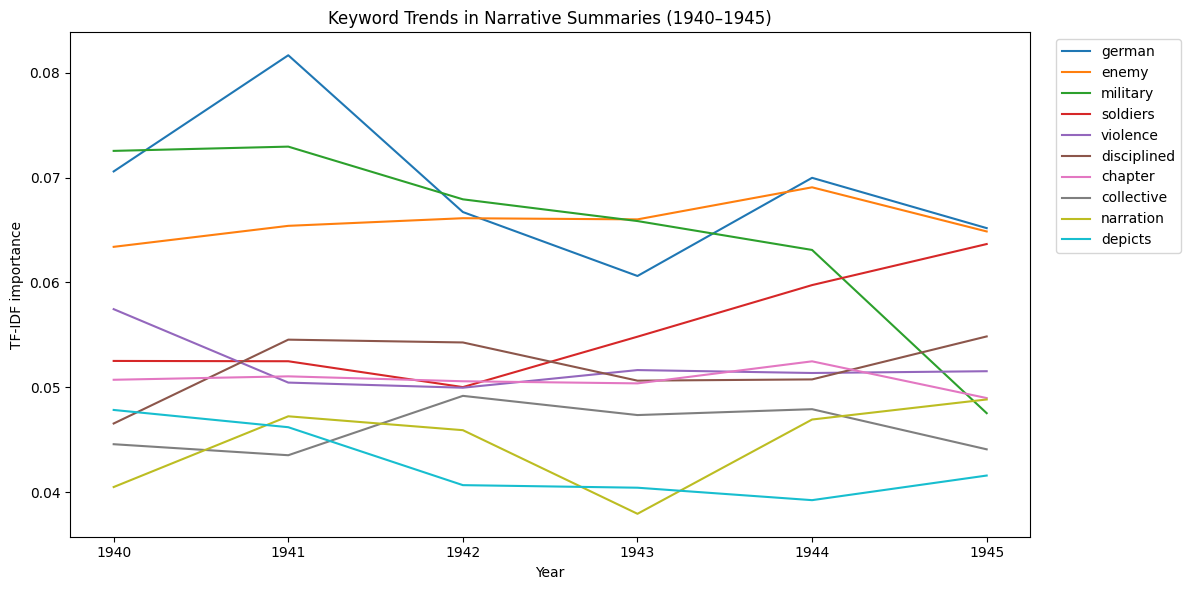

In [80]:
important_words = yearly_keywords.mean().nlargest(10).index

plt.figure(figsize=(12,6))

for word in important_words:
    plt.plot(yearly_keywords.index, yearly_keywords[word], label=word)

plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.title("Keyword Trends in Narrative Summaries (1940–1945)")
plt.ylabel("TF-IDF importance")
plt.xlabel("Year")

plt.tight_layout()
plt.show()

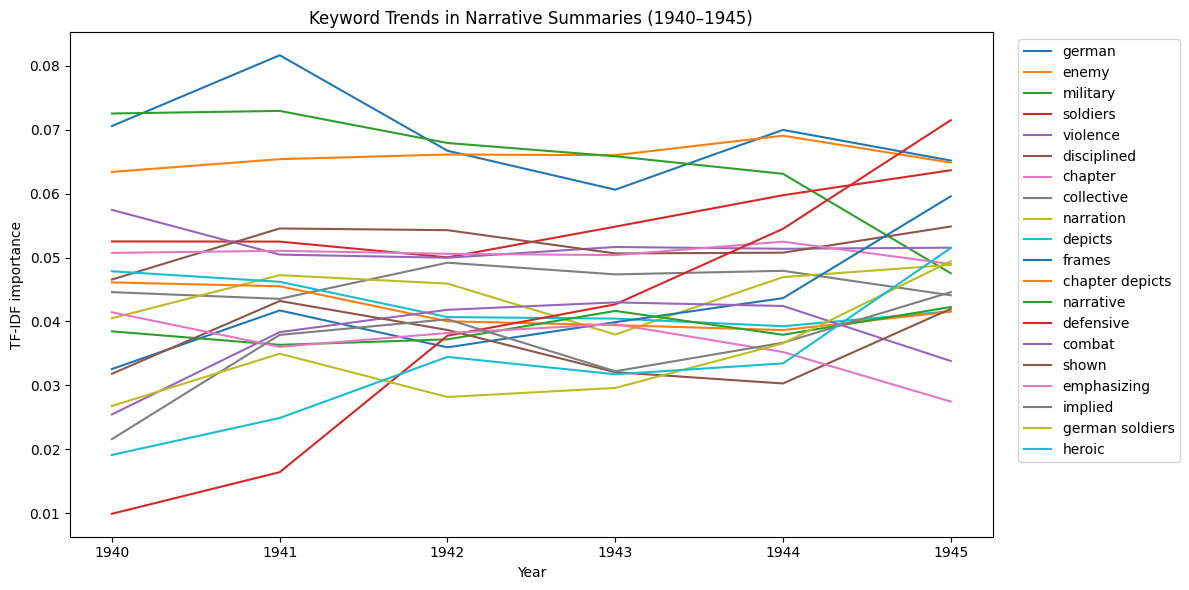

In [81]:
important_words = yearly_keywords.mean().nlargest(20).index

plt.figure(figsize=(12,6))

for word in important_words:
    plt.plot(yearly_keywords.index, yearly_keywords[word], label=word)

plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.title("Keyword Trends in Narrative Summaries (1940–1945)")
plt.ylabel("TF-IDF importance")
plt.xlabel("Year")

plt.tight_layout()
plt.show()

In [97]:
bigrams = [w for w in terms if " " in w]
bigrams

['absence direct',
 'absence enemy',
 'absence explicit',
 'absence violence',
 'action defensive',
 'action narration',
 'actions defensive',
 'actions heroic',
 'actions necessary',
 'administrative normality',
 'administrative routine',
 'adult soldiers',
 'aerial attacks',
 'aerial combat',
 'anglo american',
 'anti aircraft',
 'boat crews',
 'chapter centers',
 'chapter depicts',
 'chapter emphasizes',
 'chapter focuses',
 'chapter frames',
 'chapter highlights',
 'chapter portrays',
 'chapter presents',
 'chapter showcases',
 'chapter shows',
 'chapter visually',
 'civilizing mission',
 'collective action',
 'collective discipline',
 'collective effort',
 'collective engaged',
 'collective force',
 'collective german',
 'collective heroism',
 'collective military',
 'collective resolve',
 'collective strength',
 'combat enemy',
 'combat operations',
 'combat violence',
 'conflict defensive',
 'constructed criminal',
 'constructing enemy',
 'construction enemy',
 'coordinated acti

Try simple topic modeling with TF-IDF and Non-Negative Matrix Factorization (NMF)

In [83]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=1000,
    ngram_range=(1,2),   # include bigrams
    min_df=5             # ignore extremely rare phrases
)

X = vectorizer.fit_transform(texts)

terms = vectorizer.get_feature_names_out()

n_topics = 5

nmf = NMF(n_components=n_topics, random_state=42)

W = nmf.fit_transform(X)   # chapter-topic matrix
H = nmf.components_        # topic-term matrix

n_top_words = 10

for topic_idx, topic in enumerate(H):
    top_terms = [terms[i] for i in topic.argsort()[-n_top_words:]]
    print(f"\nTopic {topic_idx}")
    print(", ".join(top_terms))


Topic 0
military, destruction, inevitable, enemy, soviet, german military, forces, advancing, victory, german

Topic 1
chapter depicts, depicts, normality, soldiers, military, presence, occupation, orderly, routine, administrative

Topic 2
actions, struggle, narration frames, conditions, german, frames, harsh, german soldiers, soldiers, defensive

Topic 3
centers, narrative, enemy, individual, visual, depiction, explicit, collective, unity, military

Topic 4
collective, coordinated, directly, enemy, shown, prowess, violence implied, technical, technological, implied


In [84]:
# dominant topic for each document
dominant_topic = np.argmax(W, axis=1)

df["text_topic"] = dominant_topic

for topic in range(n_topics):
    print(f"\n{'='*40}")
    print(f"Topic {topic}")
    
    examples = df[df["text_topic"] == topic]["narrative_summary"].head(5)
    print(examples)


Topic 0
33    High-ranking German officers, including Hitler...
32    The chapter visually highlights disciplined Ge...
31    The newsreel chapter depicts the aftermath of ...
30    The chapter presents disciplined, invulnerable...
29    German troops are depicted as a cohesive, disc...
Name: narrative_summary, dtype: str

Topic 1
35      The chapter visually depicts large groups of d...
11      The chapter depicts disciplined German troops ...
9       This chapter presents Organization Todt as eff...
8       This chapter depicts German military and NSV p...
2727    The chapter depicts a military bicycle unit en...
Name: narrative_summary, dtype: str

Topic 2
37      This chapter depicts German soldiers in discip...
7       The chapter presents disciplined German soldie...
2757    The chapter depicts disciplined, emotionally r...
2747    This chapter frames German military personnel ...
2746    The chapter depicts disciplined groups of Germ...
Name: narrative_summary, dtype: str

Topi

Compare topics to our coded narratives:

In [85]:
topic_profile = df.groupby("text_topic")[all_dummy_cols].mean()
topic_profile

,narrative_framing_administrative_normality,narrative_framing_civilizational_struggle,narrative_framing_collective_military,narrative_framing_comradely_front,narrative_framing_cultural_guardianship,narrative_framing_defensive_war,narrative_framing_heroic_combat,narrative_framing_humanitarian_relief,narrative_framing_inevitable_victory,narrative_framing_liberation_mission,...,actor_configuration_enemy_focus,actor_configuration_individual_hero,actor_configuration_mixed_interaction,violence_visibility_absent,violence_visibility_implied,violence_visibility_shown,agency_level_high,agency_level_low,agency_level_medium,agency_level_none
text_topic,,,,,,,,,,,,,,,,,,,,,
0,0.105263,0.033835,0.000000,0.191729,0.007519,0.233083,0.898496,0.007519,0.703008,0.063910,...,0.488722,0.022556,0.003759,0.056391,0.894737,0.097744,0.977444,0.003759,0.018797,0.000000
1,0.884615,0.004808,0.000000,0.411058,0.062500,0.048077,0.036058,0.069712,0.045673,0.007212,...,0.057692,0.021635,0.021635,0.882212,0.117788,0.000000,0.367788,0.048077,0.584135,0.000000
2,0.146341,0.027439,0.000000,0.585366,0.009146,0.814024,0.777439,0.006098,0.103659,0.012195,...,0.195122,0.057927,0.000000,0.082317,0.875000,0.091463,0.966463,0.003049,0.030488,0.000000
3,0.362319,0.052174,0.002899,0.649275,0.066667,0.057971,0.504348,0.011594,0.231884,0.005797,...,0.005797,0.347826,0.002899,0.713043,0.281159,0.008696,0.791304,0.017391,0.185507,0.005797
4,0.237467,0.000000,0.000000,0.337731,0.002639,0.197889,0.781003,0.005277,0.382586,0.002639,...,0.145119,0.079156,0.002639,0.116095,0.873351,0.023747,0.978892,0.002639,0.018470,0.000000


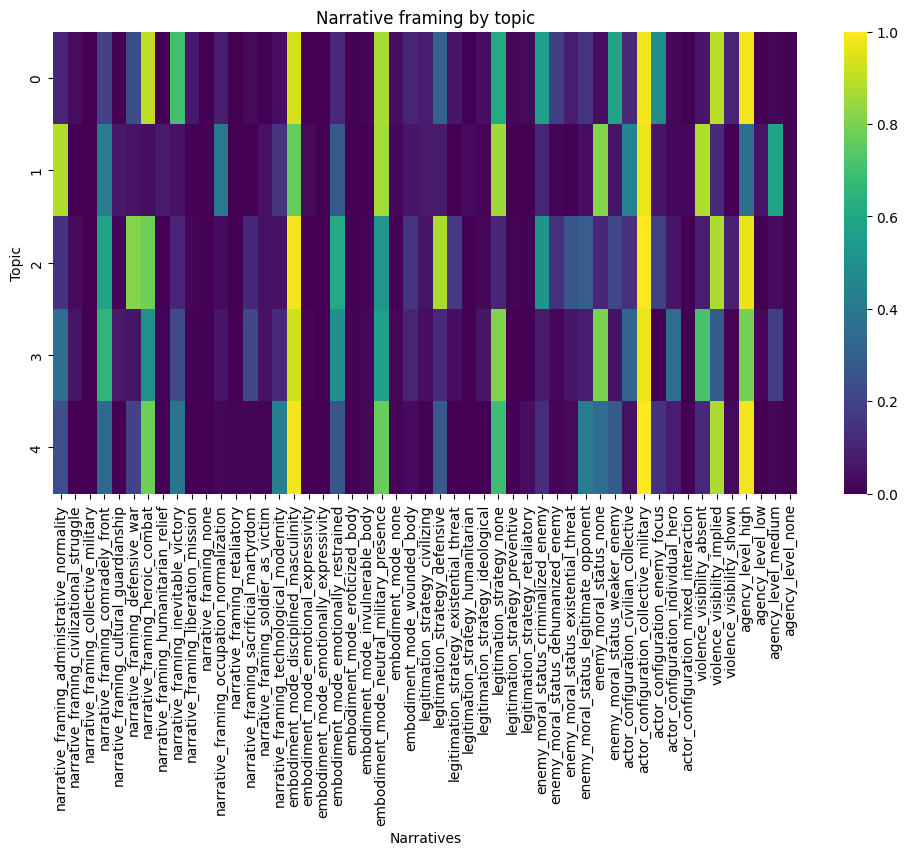

In [86]:
plt.figure(figsize=(12,6))
sns.heatmap(topic_profile, cmap="viridis")

plt.title("Narrative framing by topic")
plt.ylabel("Topic")
plt.xlabel("Narratives")

plt.show()

Find topic trends:

In [87]:
topic_trend = df.groupby(["year","text_topic"]).size().unstack().fillna(0)

topic_trend_prop = topic_trend.div(topic_trend.sum(axis=1), axis=0)

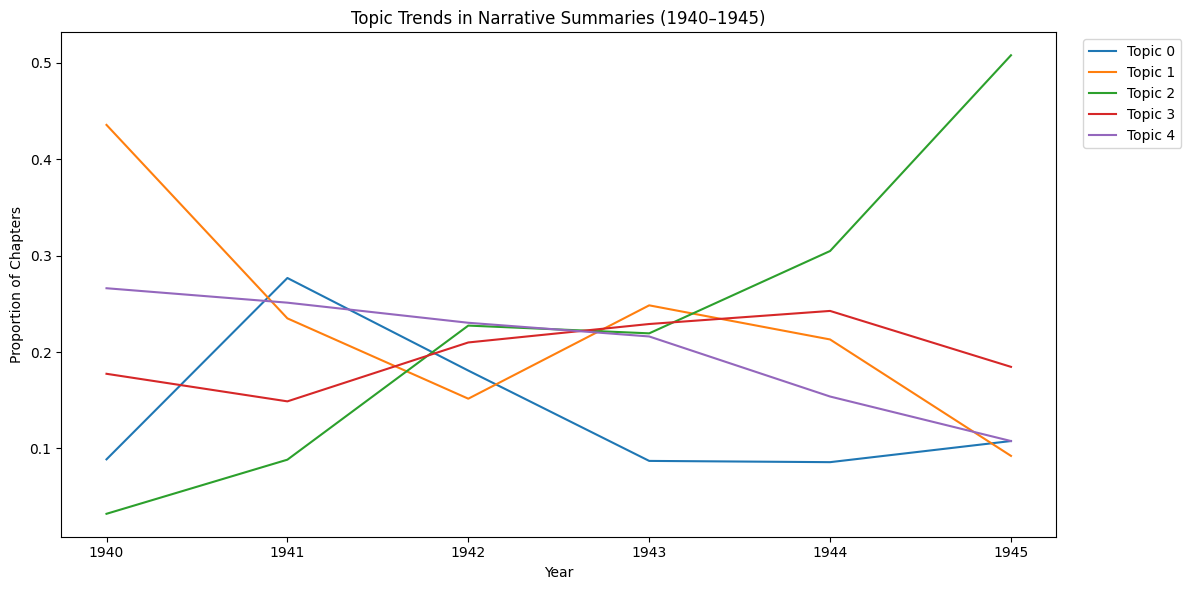

In [88]:
topic_trend = df.groupby(["year", "text_topic"]).size().unstack().fillna(0)

topic_trend_prop = topic_trend.div(topic_trend.sum(axis=1), axis=0)


plt.figure(figsize=(12,6))

for col in topic_trend_prop.columns:
    plt.plot(topic_trend_prop.index, topic_trend_prop[col], label=f"Topic {col}")

plt.title("Topic Trends in Narrative Summaries (1940–1945)")
plt.xlabel("Year")
plt.ylabel("Proportion of Chapters")

plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()

plt.show()